In [1]:
import os
import pandas as pd

print("File tersedia di input:")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# 2. Definisikan path dataset (sesuaikan dengan hasil print di atas)
# Contoh untuk dataset Iris yang umum di Kaggle
DATA_PATH = '/kaggle/input/iris/Iris.csv'

# 3. Baca dataset sebagai input
try:
    df = pd.read_csv(DATA_PATH)
    print("\nDataset berhasil dibaca!")
    print(f"Ukuran Data: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("Error: File tidak ditemukan. Pastikan Anda sudah melakukan 'Add Input' dataset Iris.")

File tersedia di input:
/kaggle/input/iris/Iris.csv
/kaggle/input/iris/database.sqlite

Dataset berhasil dibaca!
Ukuran Data: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Akurasi Model: 1.00


Text(0.5, 1.0, 'Iris Sepal Distribution')

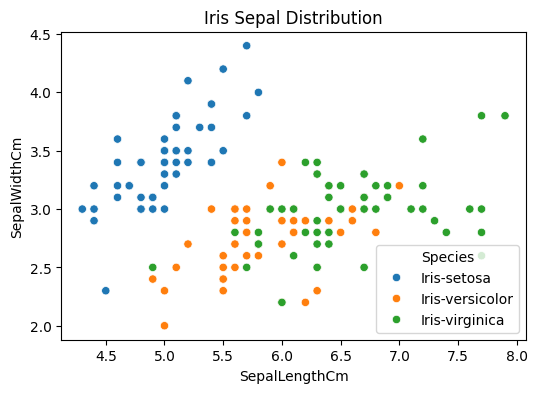

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing sederhana
X = df.drop(['Id', 'Species'], axis=1)  # fitur
y = df['Species']                       # target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Training model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# Evaluasi
acc = accuracy_score(y_test, model.predict(X_test))
print(f"Akurasi Model: {acc:.2f}")

# Membuat visualisasi (untuk disimpan pada langkah berikutnya)
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df['SepalLengthCm'], y=df['SepalWidthCm'], hue=df['Species'])
plt.title("Iris Sepal Distribution")

In [3]:
import os
import joblib
import zipfile

# Struktur direktori keluaran
OUTPUT_BASE = '/kaggle/working'
MODELS_DIR = os.path.join(OUTPUT_BASE, 'models_artifacts')
REPORTS_DIR = os.path.join(OUTPUT_BASE, 'reports')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

# 1. Simpan model (.pkl)
model_filename = os.path.join(MODELS_DIR, 'iris_knn_model.pkl')
joblib.dump(model, model_filename)
print(f"Model disimpan di: {model_filename}")

# 2. Simpan plot visualisasi (.png)
plot_filename = os.path.join(REPORTS_DIR, 'iris_sepal_plot.png')
plt.savefig(plot_filename)
print(f"Gambar disimpan di: {plot_filename}")

# 3. Kemas model dan laporan ke file ZIP
zip_filename = os.path.join(OUTPUT_BASE, 'kaggle_outputs.zip')
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as bundle:
    for folder in (MODELS_DIR, REPORTS_DIR):
        for root, _, files in os.walk(folder):
            for name in files:
                file_path = os.path.join(root, name)
                arcname = os.path.relpath(file_path, OUTPUT_BASE)
                bundle.write(file_path, arcname)
print(f"ZIP berisi artefak model dan laporan: {zip_filename}")

Model disimpan di: /kaggle/working/models_artifacts/iris_knn_model.pkl
Gambar disimpan di: /kaggle/working/reports/iris_sepal_plot.png
ZIP berisi artefak model dan laporan: /kaggle/working/kaggle_outputs.zip


<Figure size 640x480 with 0 Axes>